# 243: Does a learned combination of alphabets find domains better than one alphabet?

Notebook 242 combined alphabets by hand (rank products, then the best subset for BCL2) and
found nothing that held up: what helped BCL2 helped the control just as much, and the best
subset was picked on the answer. The principled version learns the combination from labels
that are not BCL2 or CD47.

**Data.** The 998 human proteins with a Pfam domain in the midi-plus truth set, searched
all against all with every arm of the notebook 241 sweep (one alphabet at one k, 16 to 44
bits per seed; `243_pfam998_search.py`).

**Unit: a matched region, pooled across arms.** Every region between the same query and
target that lies on the same diagonal (within 10 residues) and overlaps on the query side
is one candidate, whichever alphabets and k found it. kmerseek regions are ungapped, so the
same aligned stretch lies on the same diagonal in every alphabet.

**Label.** Correct when the candidate's query span and target span each overlap a domain of
the same Pfam family by at least 20% of the span (PR #44's rule).

**Split.** The truth set's own split by Pfam family: the model is fitted on the "selection"
families and scored on the "heldout" families, which it never sees. The Bcl-2 family is
carried by one protein in the set (BAK1, held out), so no Bcl-2 pair is in training and
Ced9 → BCL2 is a test the model was not fitted to.

**Features**, chosen to mean the same in a 998-protein and a 19_732-protein database:
for each of the 19 alphabets, whether any of its arms found the candidate, the highest seed
information (bits) at which it still did, the best mean IDF divided by ln(number of
proteins in the database), the best bit score, and the most shared k-mers; plus the
candidate's length, both proteins' lengths, the number of alphabets and arms that found it,
and the membrane-helix-like hydrophobic windows in each span (the sticky-target effect of
notebook 242).

**The test.** Three nested models: length and hydrophobic make-up only; that plus
hp_lehninger2's own values; that plus all 19 alphabets. Combining alphabets helps only if
the third beats the second on families the model has not seen.

In [1]:
import sys
from pathlib import Path

import numpy as np
import polars as pl
from sklearn.metrics import average_precision_score, precision_recall_curve

sys.path.insert(0, str(Path.cwd()))
import alphabet_logreg_utils as lr

pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_width_chars(220)
pl.Config.set_fmt_str_lengths(60)
FIG = lr.FIG

import json
plan = json.loads((lr.SWEEP / "plan.json").read_text())
done = {f.stem for f in (lr.PF998 / "regions").glob("*.parquet")}
missing = [p for p in plan if f"{p['alphabet']}.k{p['ksize']}" not in done]
print(f"{len(done)} of {len(plan)} arms searched on the 998 proteins"
      + (f"; missing {len(missing)}, from {min(p['bits'] for p in missing):.1f} to {max(p['bits'] for p in missing):.1f} bits"
         if missing else ""))

# Every arm must have been searched the way the same arm was searched against the human
# proteome (extended or exact); otherwise a feature means different things in training and
# when the model is applied.
spec = __import__("importlib.util").util.spec_from_file_location("s243", "243_pfam998_search.py")
s243 = __import__("importlib.util").util.module_from_spec(spec); spec.loader.exec_module(s243)
bad = []
for f in sorted((lr.PF998 / "regions").glob("*.parquet")):
    d = pl.read_parquet(f, columns=None).head(1)
    if "extended" not in d.columns:
        bad.append((f.stem, "searched before the settings were matched"))
    elif d.height and bool(d["extended"][0]) != s243.human_setting(f.stem)[0]:
        bad.append((f.stem, "extended here" if d["extended"][0] else "exact here"))
assert not bad, f"arms searched differently from the human search, rerun them: {bad}"
print("every searched arm matches its human search setting (extended or exact)")

T = lr.training_table()
counts = pl.read_csv(lr.PF998 / "candidate_counts.csv", schema_overrides={"split": pl.Utf8})
print("every candidate, by split (null = touches families of both splits, left out):")
print(counts.sort("split", "correct"))
print("\nkept for the model (every correct one; 50 incorrect per correct one in training; 3 M incorrect held-out,")
print("each kept incorrect candidate weighted by how many it stands for):")
print(T.group_by("split", "correct").agg(pl.len().alias("kept"), pl.col("weight").sum().round(0).alias("stands_for")).sort("split", "correct"))
train = T.filter(pl.col("split") == "selection")
test = T.filter(pl.col("split") == "heldout")

152 of 152 arms searched on the 998 proteins


every searched arm matches its human search setting (extended or exact)
every candidate, by split (null = touches families of both splits, left out):
shape: (4, 3)
┌───────────┬─────────┬────────────┐
│ split     ┆ correct ┆ candidates │
│ ---       ┆ ---     ┆ ---        │
│ str       ┆ bool    ┆ i64        │
╞═══════════╪═════════╪════════════╡
│ heldout   ┆ false   ┆ 19514803   │
│ heldout   ┆ true    ┆ 18189      │
│ selection ┆ false   ┆ 21447310   │
│ selection ┆ true    ┆ 27859      │
└───────────┴─────────┴────────────┘

kept for the model (every correct one; 50 incorrect per correct one in training; 3 M incorrect held-out,
each kept incorrect candidate weighted by how many it stands for):


shape: (4, 4)
┌───────────┬─────────┬─────────┬─────────────┐
│ split     ┆ correct ┆ kept    ┆ stands_for  │
│ ---       ┆ ---     ┆ ---     ┆ ---         │
│ str       ┆ bool    ┆ u32     ┆ f64         │
╞═══════════╪═════════╪═════════╪═════════════╡
│ heldout   ┆ false   ┆ 3000000 ┆ 1.9514803e7 │
│ heldout   ┆ true    ┆ 18189   ┆ 18189.0     │
│ selection ┆ false   ┆ 1392950 ┆ 2.144731e7  │
│ selection ┆ true    ┆ 27859   ┆ 27859.0     │
└───────────┴─────────┴─────────┴─────────────┘


## 1. On families it has never seen, does combining alphabets help?

Precision-recall on the held-out families for the three nested models, with three single
features beside them. Average precision is the area under each curve; chance is the share
of candidates that are correct. The held-out incorrect candidates are a random 3 M, each
weighted by how many it stands for, so the curves estimate those over every candidate.

/Users/olga/code/2024-kmerseek-analysis/.claude/worktrees/alphabet-ensemble/notebooks/hp_conservation_utils.py:277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


shape: (6, 4)
┌─────────────────────────────────────┬───────────────────────────┬─────────────────────────┬─────────────────────────┐
│ ranker                              ┆ heldout_average_precision ┆ recall_at_precision_0.5 ┆ recall_at_precision_0.1 │
│ ---                                 ┆ ---                       ┆ ---                     ┆ ---                     │
│ str                                 ┆ f64                       ┆ f64                     ┆ f64                     │
╞═════════════════════════════════════╪═══════════════════════════╪═════════════════════════╪═════════════════════════╡
│ length and hydrophobic make-up only ┆ 0.011                     ┆ 0.0                     ┆ 0.0225                  │
│ + hp_lehninger2's own values        ┆ 0.0289                    ┆ 0.0215                  ┆ 0.0375                  │
│ + all 19 alphabets                  ┆ 0.0463                    ┆ 0.0351                  ┆ 0.0691                  │
│ number of alphabets that

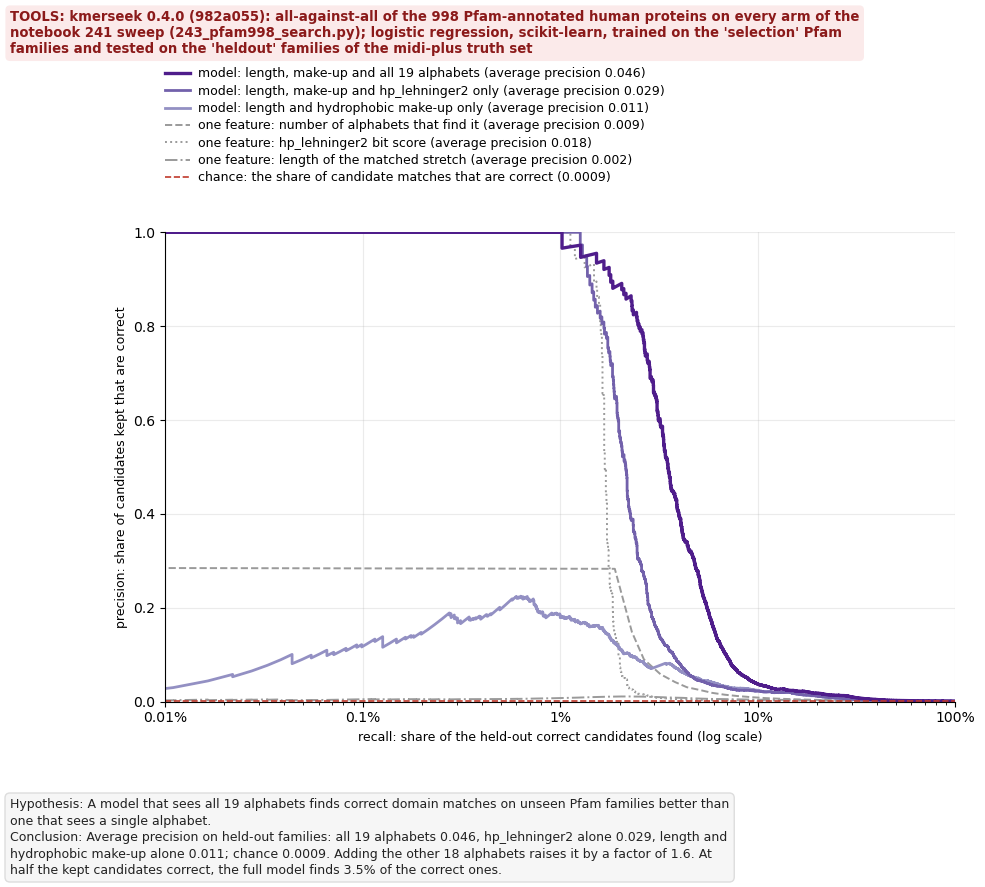

In [2]:
models, infos, curves = {}, {}, {}
y = test["correct"].to_numpy()
w = test["weight"].to_numpy()
for name, feats in lr.FEATURE_SETS.items():
    m, info = lr.fit_model(train, feats)
    models[name], infos[name] = m, info
    p = m.predict_proba(test.select(feats).to_numpy())[:, 1]
    prec, rec, _ = precision_recall_curve(y, p, sample_weight=w)
    curves[name] = (rec, prec, average_precision_score(y, p, sample_weight=w))
for name, col in [("number of alphabets that find it", "n_alphabets"),
                  ("hp_lehninger2 bit score", "hp_lehninger2__bit_score"),
                  ("candidate length", "log_span_length")]:
    s = test[col].to_numpy()
    prec, rec, _ = precision_recall_curve(y, s, sample_weight=w)
    curves[name] = (rec, prec, average_precision_score(y, s, sample_weight=w))
def recall_at(rec, prec, target):
    ok = prec >= target
    return float(rec[ok].max()) if ok.any() else 0.0
ap = pl.DataFrame({"ranker": list(curves),
                   "heldout_average_precision": [round(v[2], 4) for v in curves.values()],
                   "recall_at_precision_0.5": [round(recall_at(v[0], v[1], 0.5), 4) for v in curves.values()],
                   "recall_at_precision_0.1": [round(recall_at(v[0], v[1], 0.1), 4) for v in curves.values()]})
full, one, base = (curves[k][2] for k in ["+ all 19 alphabets", "+ hp_lehninger2's own values", "length and hydrophobic make-up only"])
lr.fig_heldout(
    curves, float((w * y).sum() / w.sum()), FIG / "243_heldout_precision_recall.png",
    hypothesis="A model that sees all 19 alphabets finds correct domain matches on unseen Pfam families better than one that sees a single alphabet.",
    conclusion=(f"Average precision on held-out families: all 19 alphabets {full:.3f}, hp_lehninger2 alone {one:.3f}, "
                f"length and hydrophobic make-up alone {base:.3f}; chance {(w * y).sum() / w.sum():.4f}. "
                + ("Adding the other 18 alphabets raises it by a factor of " + f"{full / one:.1f}." if full > one
                   else "Adding the other 18 alphabets does not raise it.")
                + f" At half the kept candidates correct, the full model finds {recall_at(*curves['+ all 19 alphabets'][:2], 0.5):.1%} of the correct ones."),
)
print(ap)
print({k: {kk: v[kk] for kk in ("C", "n_pos", "n_neg")} for k, v in infos.items()})

## 2. What the full model weighs

Standardised coefficients: how much one standard deviation of each feature moves the
log-odds that a candidate is correct, with every other feature held fixed. Alphabets
overlap heavily, so a single coefficient is not a clean measure of one alphabet's worth;
section 1's nested comparison is.

/Users/olga/code/2024-kmerseek-analysis/.claude/worktrees/alphabet-ensemble/notebooks/hp_conservation_utils.py:277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


shape: (8, 2)
┌──────────────────────────────────────┬─────────────┐
│ feature                              ┆ coefficient │
│ ---                                  ┆ ---         │
│ str                                  ┆ f64         │
╞══════════════════════════════════════╪═════════════╡
│ length of the matched stretch        ┆ 0.292       │
│ sdm12, best bit score                ┆ 0.23        │
│ mmseqs12, best bit score             ┆ 0.18        │
│ hp_thomas_dill_no_c2, best bit score ┆ 0.15        │
│ hp_kyte_doolittle2, best bit score   ┆ 0.143       │
│ uniprot18, best bit score            ┆ 0.12        │
│ hp_thomas_dill2, best bit score      ┆ 0.111       │
│ gbmr4, best bit score                ┆ 0.101       │
└──────────────────────────────────────┴─────────────┘
shape: (5, 2)
┌─────────────────────────────────────┬─────────────┐
│ feature                             ┆ coefficient │
│ ---                                 ┆ ---         │
│ str                                 ┆ 

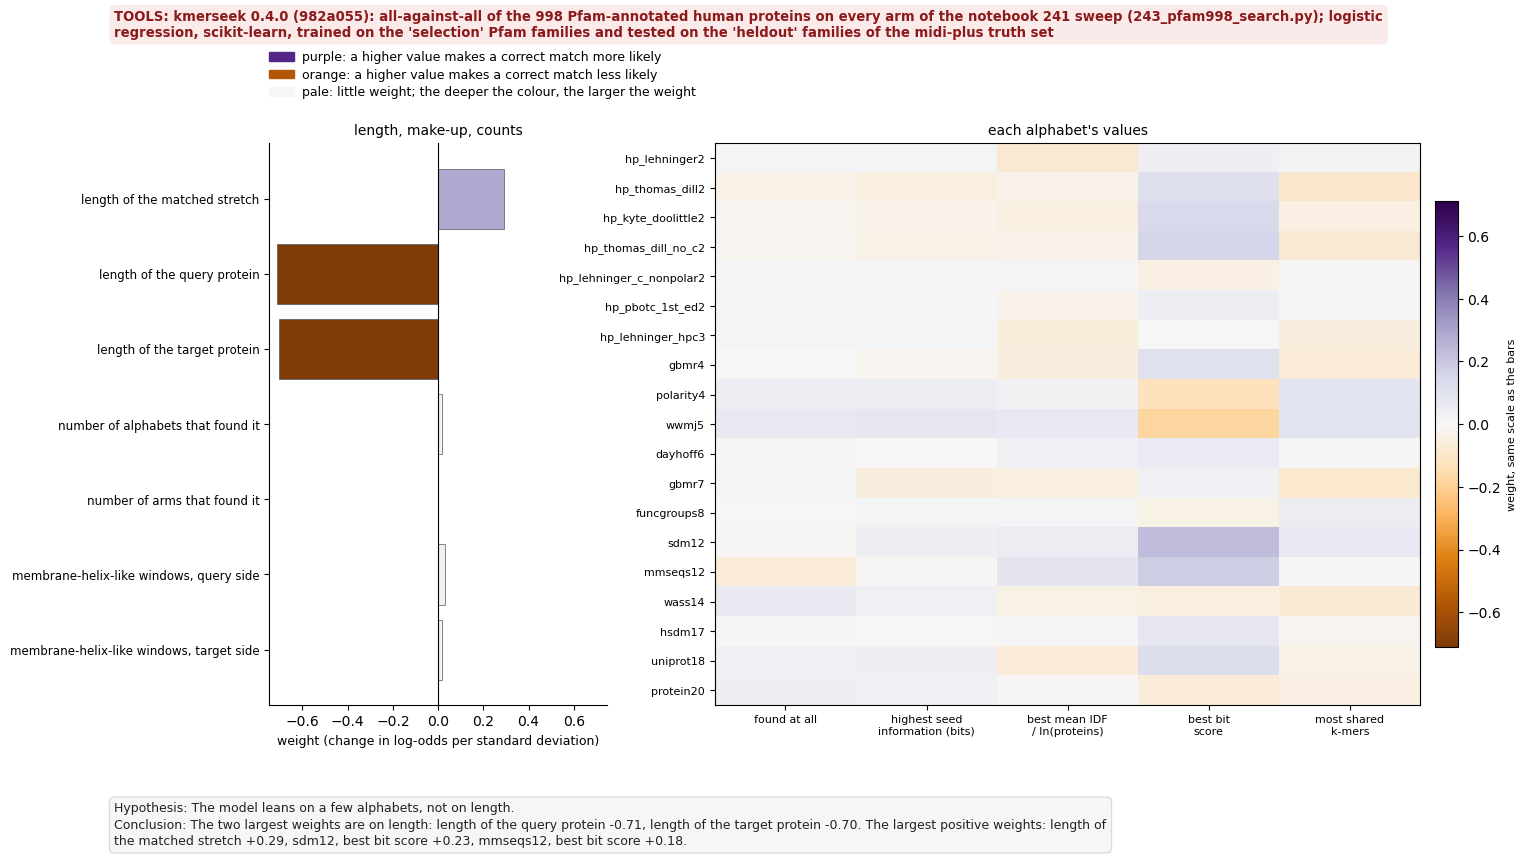

In [3]:
m_full = models["+ all 19 alphabets"]
cf = dict(zip(lr.FEATURES, m_full.named_steps["logisticregression"].coef_[0]))
order = sorted(cf, key=cf.get, reverse=True)
top = pl.DataFrame({"feature": [lr.feature_label(f) for f in order[:8]], "coefficient": [round(float(cf[f]), 3) for f in order[:8]]})
bottom = pl.DataFrame({"feature": [lr.feature_label(f) for f in order[::-1][:5]], "coefficient": [round(float(cf[f]), 3) for f in order[::-1][:5]]})
coef = lr.fig_coefficients(
    m_full, lr.FEATURES, FIG / "243_model_coefficients.png",
    hypothesis="The model leans on a few alphabets, not on length.",
    conclusion=("The two largest weights are on length: " + ", ".join(f"{f} {c:+.2f}" for f, c in bottom.rows()[:2])
                + ". The largest positive weights: " + ", ".join(f"{f} {c:+.2f}" for f, c in top.rows()[:3]) + "."),
)
print(top); print(bottom)

## 3. Applied to the three test cases

The model is applied to notebook 241's searches of Ced9, P66 and BHF against the 19_732
human proteins, pooled into candidates in the same way. A target's score is its best
candidate's probability. The single features are ranked the same way for comparison.

/Users/olga/code/2024-kmerseek-analysis/.claude/worktrees/alphabet-ensemble/notebooks/hp_conservation_utils.py:277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


shape: (24, 6)
┌───────┬─────────┬─────────────────────────┬─────────┬───────────┬───────────────┐
│ query ┆ partner ┆ ranker                  ┆ rank    ┆ n_targets ┆ partner_value │
│ ---   ┆ ---     ┆ ---                     ┆ ---     ┆ ---       ┆ ---           │
│ str   ┆ str     ┆ str                     ┆ f64     ┆ i64       ┆ f64           │
╞═══════╪═════════╪═════════════════════════╪═════════╪═══════════╪═══════════════╡
│ Ced9  ┆ BCL2    ┆ model                   ┆ 3539.0  ┆ 19720     ┆ 0.017176      │
│ Ced9  ┆ BCL2    ┆ number of alphabets     ┆ 2773.5  ┆ 19720     ┆ 9.0           │
│ Ced9  ┆ BCL2    ┆ hp_lehninger2 bit score ┆ 7266.0  ┆ 19720     ┆ 18.039978     │
│ Ced9  ┆ BCL2    ┆ candidate length        ┆ 6112.5  ┆ 19720     ┆ 5.068904      │
│ Ced9  ┆ CD47    ┆ model                   ┆ 3388.0  ┆ 19720     ┆ 0.01761       │
│ Ced9  ┆ CD47    ┆ number of alphabets     ┆ 1641.0  ┆ 19720     ┆ 10.0          │
│ Ced9  ┆ CD47    ┆ hp_lehninger2 bit score ┆ 6918.0  ┆ 19720

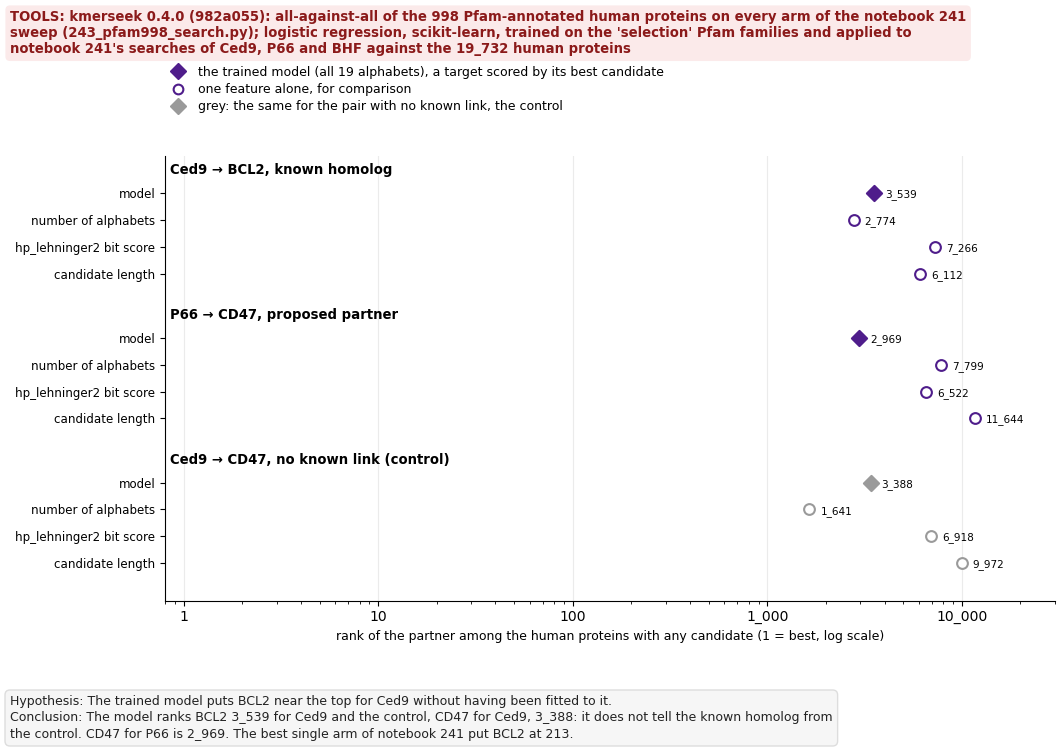

In [4]:
full_model = models["+ all 19 alphabets"]
rows, tops = [], {}
for q in ["Ced9", "P66", "BHF"]:
    Q = lr.query_table(q)
    ts = lr.target_scores(Q, full_model.predict_proba(Q.select(lr.FEATURES).to_numpy())[:, 1])
    tops[q] = (ts.sort("prob", descending=True).head(10)
                 .select("gene", "prob", "n_alphabets", pl.col("hydrophobic_windows_target").exp().sub(1).round(0).cast(pl.Int64)
                         .alias("membrane_helix_like_windows_in_match")))
    for partner in ["BCL2", "CD47"]:
        idx = ts["gene"].to_list().index(partner) if partner in ts["gene"].to_list() else None
        if idx is None:
            continue
        for ranker, col in [("model", "prob"), ("number of alphabets", "n_alphabets"),
                            ("hp_lehninger2 bit score", "hp_lehninger2__bit_score"), ("candidate length", "log_span_length")]:
            rows.append(dict(query=q, partner=partner, ranker=ranker, rank=lr.midrank(ts[col].to_numpy(), idx),
                             n_targets=ts.height, partner_value=float(ts[col][idx])))
app = pl.DataFrame(rows)
b = app.filter((pl.col("query") == "Ced9") & (pl.col("partner") == "BCL2") & (pl.col("ranker") == "model"))["rank"][0]
c = app.filter((pl.col("query") == "P66") & (pl.col("partner") == "CD47") & (pl.col("ranker") == "model"))["rank"][0]
k = app.filter((pl.col("query") == "Ced9") & (pl.col("partner") == "CD47") & (pl.col("ranker") == "model"))["rank"][0]
lr.fig_application(
    app, FIG / "243_model_on_three_cases.png",
    hypothesis="The trained model puts BCL2 near the top for Ced9 without having been fitted to it.",
    conclusion=(f"The model ranks BCL2 {b:_.0f} for Ced9 and the control, CD47 for Ced9, {k:_.0f}: it does not tell the "
                f"known homolog from the control. CD47 for P66 is {c:_.0f}. The best single arm of notebook 241 put BCL2 at 213."),
)
print(app)
for q, t in tops.items():
    print(f"\n{q}: the 10 targets the model ranks highest"); print(t)

## 4. Conclusions

1. **On Pfam families the model never saw, combining alphabets helps.** Average
   precision is 0.046 with all 19 alphabets, 0.029 with hp_lehninger2 alone and 0.011 with
   length and hydrophobic make-up alone; chance is 0.0009. The other 18 alphabets add a
   factor of 1.6.
2. **The gain is at the very top of the list only.** With half the kept matches correct,
   the full model finds 3.5% of the correct matches and the hp_lehninger2 model 2.2%. By 10%
   recall every ranker is close to chance.
3. **The largest weights are on protein length, not on any alphabet.** The query's and
   the target's length weigh -0.71 and -0.70 per standard deviation: a match between two
   short proteins is more often a shared Pfam family. The largest alphabet weights are on
   bit scores: sdm12 +0.23, mmseqs12 +0.18, and three 2-letter hydrophobic-polar alphabets
   +0.11 to +0.15.
4. **Applied to the three cases, the model does not separate BCL2 from the control.** It
   ranks BCL2 3_539 for Ced9 and CD47, which has no known link to Ced9, 3_388. It ranks CD47
   2_969 for P66. The four highest-ranked proteins for Ced9 are olfactory receptors (OR4F3,
   OR4F16, OR4F21, OR4F29), each matched over a stretch with 8 membrane-helix-like windows;
   the membrane pull that notebook 242 found is still there, although the windows are
   a feature (their weights are about +0.02).
5. **Together with notebook 242.** A random human protein of Ced9's length ranks BCL2 as
   well as Ced9 does in about one case in five, even with the best alphabets and k picked
   for each query. The trained model does no better. The limit is in what each arm sees for
   this pair, not in how the arms are combined.